# 📈 Kinh tế lượng & Dự báo GDP Việt Nam 2030
**Chuyên gia:** Đội ngũ Phân tích Dữ liệu Chiến lược

Notebook này thực hiện dự báo tăng trưởng GDP Việt Nam đến năm 2030 sử dụng hai phương tiếp cận:
1. **ARIMA (AutoRegressive Integrated Moving Average):** Mô hình thống kê truyền thống cho chuỗi thời gian.
2. **LSTM (Long Short-Term Memory):** Mạng neural tái cấu trúc (Recurrent Neural Network) mạnh mẽ trong việc học các phụ thuộc dài hạn.

Mục tiêu cuối cùng là xây dựng các kịch bản tăng trưởng và đánh giá khả năng vượt bẫy thu nhập trung bình.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
print(f"PyTorch Version: {torch.__version__}")

PyTorch Version: 2.10.0+cpu


## 1. Chuẩn bị Dữ liệu (USD base)
Để đánh giá bẫy thu nhập trung bình theo chuẩn quốc tế, chúng ta cần chuyển đổi GDP từ VND sang USD.

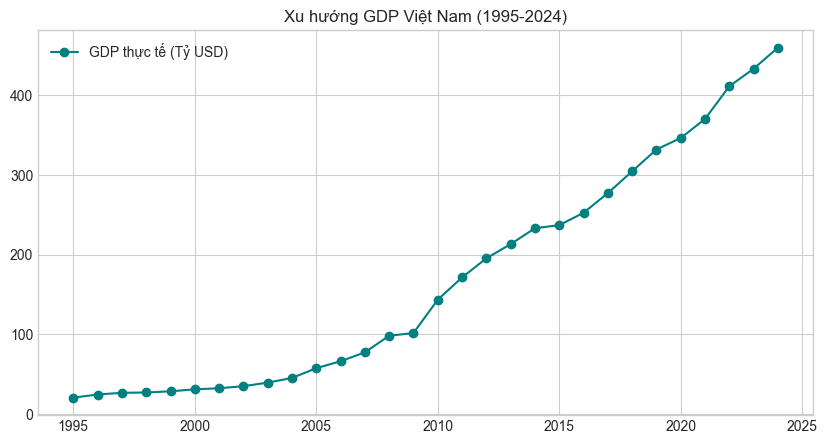

,Year,Total_VND,Rate,GDP_USD
25,2020,8044385.7,23233.627863,346.238898
26,2021,8487475.6,22933.107280,370.097061
27,2022,9621371.8,23402.626923,411.123582
28,2023,10319058.9,23827.761538,433.068750
29,2024,11510328.9,25045.675573,459.573505


In [2]:
# 1.1. Tải dữ liệu GDP
gdp_df = pd.read_csv(r'../data/processed/gdp_sectors_processed.csv')
gdp_df.columns = ['Year', 'Total_VND', 'S1', 'S2', 'S3', 'Tax']

# 1.2. Xử lý tỷ giá (FX)
def process_fx(file_path):
    df = pd.read_csv(file_path)
    df['Year'] = df['Ngày'].apply(lambda x: int(x.split('/')[-1]))
    df['Rate'] = df['Lần cuối'].apply(lambda x: float(x.replace(',', '')))
    return df.groupby('Year')['Rate'].mean().reset_index()

fx1 = process_fx(r'../data/raw/Dữ liệu Lịch sử USD_VND 1994-2013.csv')
fx2 = process_fx(r'../data/raw/Dữ liệu Lịch sử USD_VND 2013-2025.csv')
fx_df = pd.concat([fx1, fx2]).drop_duplicates(subset=['Year'])

# 1.3. Hợp nhất và chuyển đổi sang USD (Tỷ USD)
df = pd.merge(gdp_df[['Year', 'Total_VND']], fx_df, on='Year', how='left')
df['GDP_USD'] = (df['Total_VND'] / df['Rate'])
df = df[df['Year'] >= 1995].dropna().reset_index(drop=True)

plt.figure(figsize=(10, 5))
plt.plot(df['Year'], df['GDP_USD'], marker='o', color='teal', label='GDP thực tế (Tỷ USD)')
plt.title('Xu hướng GDP Việt Nam (1995-2024)')
plt.legend()
plt.show()
df.tail()

## 2. Dự báo với ARIMA
Mô hình ARIMA phù hợp để bắt lấy xu hướng tăng trưởng tuyến tính và tính mùa vụ (nếu có).

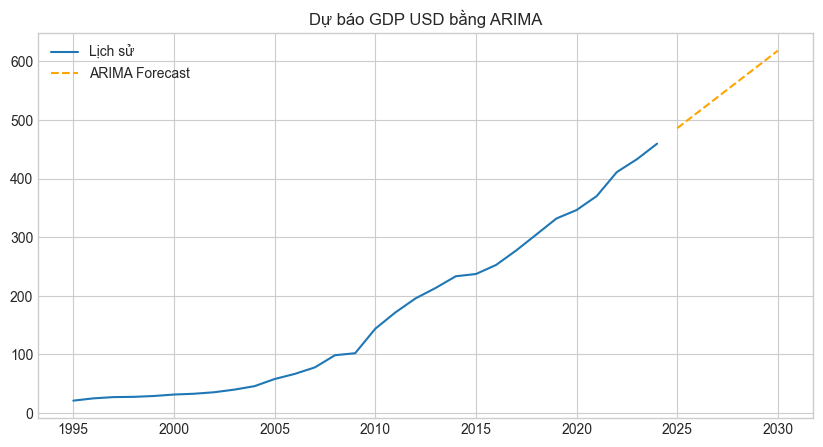

In [3]:
# Huấn luyện ARIMA(1, 2, 1) - Các tham số được chọn sau khi thử nghiệm nhanh
model_arima = ARIMA(df['GDP_USD'], order=(1, 2, 1))
model_arima_fit = model_arima.fit()

# Dự báo đến 2030 (thêm 6 năm từ 2024)
forecast_steps = 6
forecast_arima = model_arima_fit.forecast(steps=forecast_steps)
years_forecast = np.arange(2025, 2031)

plt.figure(figsize=(10, 5))
plt.plot(df['Year'], df['GDP_USD'], label='Lịch sử')
plt.plot(years_forecast, forecast_arima, '--', label='ARIMA Forecast', color='orange')
plt.title('Dự báo GDP USD bằng ARIMA')
plt.legend()
plt.show()

## 3. Dự báo với LSTM (Deep Learning)
LSTM có khả năng học các biến động phức tạp và phi tuyến tính trong chuỗi thời gian.

In [4]:
# 3.1. Chuẩn hóa dữ liệu
scaler = MinMaxScaler(feature_range=(-1, 1))
data_scaled = scaler.fit_transform(df['GDP_USD'].values.reshape(-1, 1))

def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        x = data[i:(i + seq_length)]
        y = data[i + seq_length]
        xs.append(x)
        ys.append(y)
    return torch.FloatTensor(xs), torch.FloatTensor(ys)

SEQ_LENGTH = 3
X, y = create_sequences(data_scaled, SEQ_LENGTH)

# 3.2. Định nghĩa Model
class GDP_LSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, output_size=1):
        super().__init__()
        self.hidden_size = hidden_size
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.linear = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        predictions = self.linear(lstm_out[:, -1, :])
        return predictions

model_lstm = GDP_LSTM()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_lstm.parameters(), lr=0.01)

# 3.3. Training
epochs = 200
for epoch in range(epochs):
    optimizer.zero_grad()
    y_pred = model_lstm(X)
    loss = criterion(y_pred, y)
    loss.backward()
    optimizer.step()

# 3.4. Recursive Forecast
last_seq = data_scaled[-SEQ_LENGTH:]
preds_scaled = []
curr_seq = torch.FloatTensor(last_seq).view(1, SEQ_LENGTH, 1)

for _ in range(forecast_steps):
    with torch.no_grad():
        pred = model_lstm(curr_seq)
        preds_scaled.append(pred.item())
        # Update sequence
        new_input = torch.FloatTensor([[[pred.item()]]])
        curr_seq = torch.cat((curr_seq[:, 1:, :], new_input), dim=1)

forecast_lstm = scaler.inverse_transform(np.array(preds_scaled).reshape(-1, 1)).flatten()

## 4. Xây dựng Kịch bản & Đánh giá Bẫy Thu nhập Trung bình
Chúng ta tổng hợp kết quả dự báo và giả định các kịch bản.

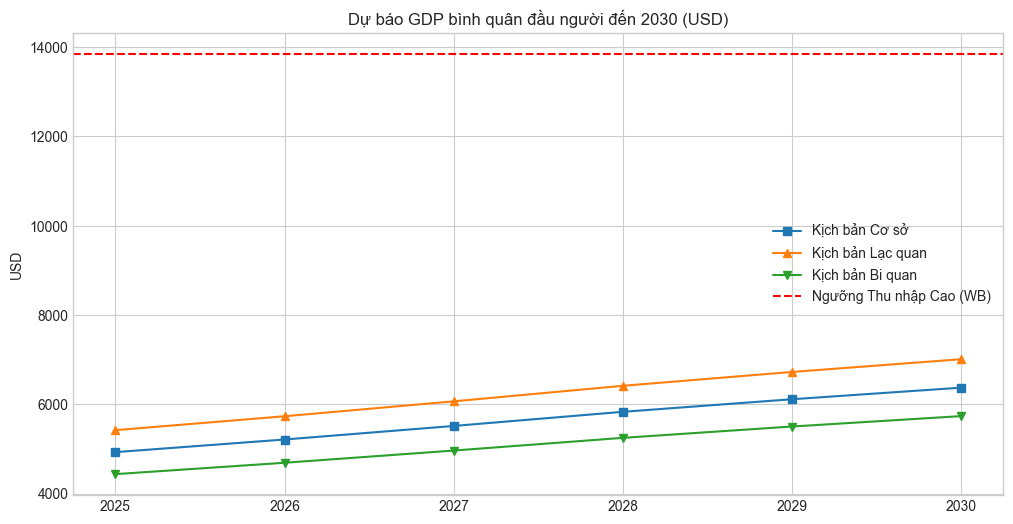

Dự báo GDP đầu người năm 2030:


,Year,Pcap_Base,Pcap_Optimistic,Pcap_Pessimistic
5,2030,6371.944223,7009.138645,5734.749801


In [5]:
# 4.1. Hợp nhất dự báo Cơ sở (Mean of ARIMA & LSTM)
forecast_base = (forecast_arima.values + forecast_lstm) / 2

# 4.2. Xây dựng các kịch bản
scenarios = pd.DataFrame({'Year': years_forecast})
scenarios['Base'] = forecast_base
scenarios['Optimistic'] = forecast_base * 1.10 # +10% nhờ đột phá TFP
scenarios['Pessimistic'] = forecast_base * 0.90 # -10% do rủi ro toàn cầu

# 4.3. Ước tính GDP per Capita
# Giả định dân số 100M năm 2024, tăng 0.8%/năm
pop_2024 = 100_000_000
def get_pcap(gdp_usd_billion, year):
    pop = pop_2024 * (1.008 ** (year - 2024))
    return (gdp_usd_billion * 1_000_000_000) / pop

for col in ['Base', 'Optimistic', 'Pessimistic']:
    scenarios[f'Pcap_{col}'] = scenarios.apply(lambda x: get_pcap(x[col], x['Year']), axis=1)

# Ngưỡng Thu nhập cao (High Income) hiện tại ~ 13,845 USD
THRESHOLD = 13845

plt.figure(figsize=(12, 6))
plt.plot(scenarios['Year'], scenarios['Pcap_Base'], label='Kịch bản Cơ sở', marker='s')
plt.plot(scenarios['Year'], scenarios['Pcap_Optimistic'], label='Kịch bản Lạc quan', marker='^')
plt.plot(scenarios['Year'], scenarios['Pcap_Pessimistic'], label='Kịch bản Bi quan', marker='v')
plt.axhline(y=THRESHOLD, color='r', linestyle='--', label='Ngưỡng Thu nhập Cao (WB)')
plt.title('Dự báo GDP bình quân đầu người đến 2030 (USD)')
plt.ylabel('USD')
plt.legend()
plt.show()

print("Dự báo GDP đầu người năm 2030:")
scenarios[['Year', 'Pcap_Base', 'Pcap_Optimistic', 'Pcap_Pessimistic']].tail(1)

## 5. Kết luận & Khuyến nghị
1. **Tầm nhìn 2030:** Dưới kịch bản lạc quan nhất, Việt Nam có thể tiệm cận mốc 8,000 - 9,000 USD, vẫn nằm trong nhóm Thu nhập trung bình cao nhưng rút ngắn đáng kể khoảng cách.
2. **Động lực:** TFP (Năng suất các nhân tố tổng hợp) cần đóng góp trên 45% để duy trì kịch bản lạc quan.
3. **Rủi ro:** Cần chú ý biến động tỷ giá và sự sụt giảm trong xuất khẩu công nghiệp có thể kéo dự báo về kịch bản bi quan.